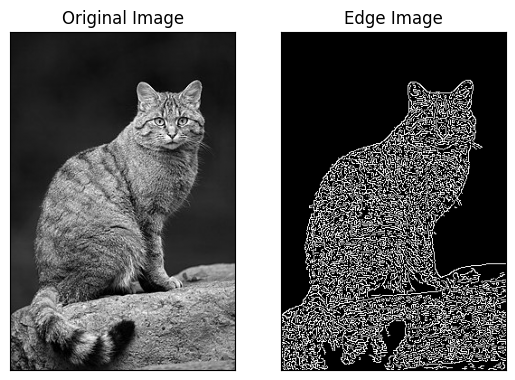

In [1]:
# Edge Detection of an Image 
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('a.jpg',0)
edges = cv2.Canny(img,100,200)

plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(edges,cmap = 'gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
plt.show()

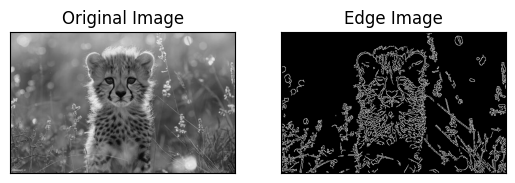

In [2]:
# Edge Detection of an Image 
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('b.jpg',0)
edges = cv2.Canny(img,100,200)

plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(edges,cmap = 'gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
plt.show()

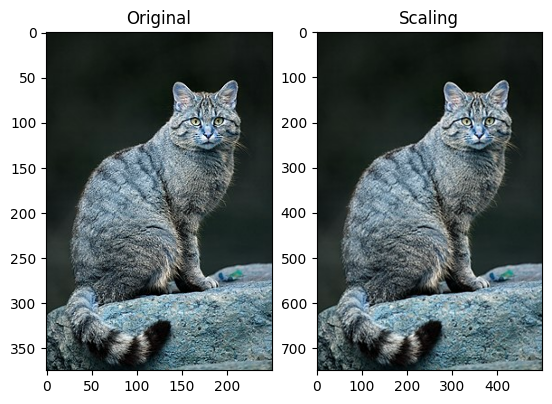

In [3]:
# Scaling an Image
import cv2
import numpy as np
from matplotlib import pyplot as plt
img = cv2.imread('a.jpg')

#res = cv2.resize(img,None,fx=2, fy=2, interpolation = cv2.INTER_CUBIC)

height, width = img.shape[:2]
res = cv2.resize(img,(2*width, 2*height), interpolation = cv2.INTER_CUBIC)

plt.subplot(121),plt.imshow(img),plt.title('Original')
#plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(res),plt.title('Scaling')
#plt.xticks([]), plt.yticks([])
plt.show()

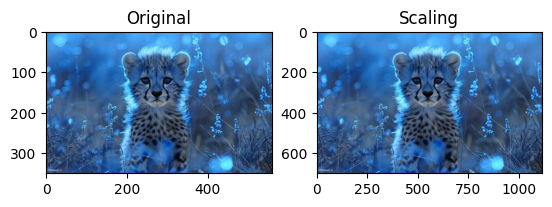

In [4]:
# Scaling an Image
import cv2
import numpy as np
from matplotlib import pyplot as plt
img = cv2.imread('b.jpg')

#res = cv2.resize(img,None,fx=2, fy=2, interpolation = cv2.INTER_CUBIC)

height, width = img.shape[:2]
res = cv2.resize(img,(2*width, 2*height), interpolation = cv2.INTER_CUBIC)

plt.subplot(121),plt.imshow(img),plt.title('Original')
#plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(res),plt.title('Scaling')
#plt.xticks([]), plt.yticks([])
plt.show()

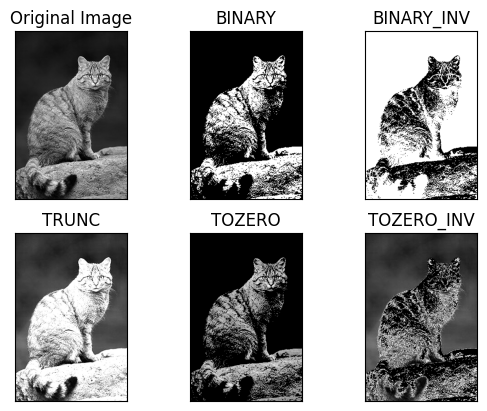

In [5]:
# program showing a thresholding process on an image
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('a.jpg',0)
ret,thresh1 = cv2.threshold(img,127,255,cv2.THRESH_BINARY)
ret,thresh2 = cv2.threshold(img,127,255,cv2.THRESH_BINARY_INV)
ret,thresh3 = cv2.threshold(img,127,255,cv2.THRESH_TRUNC)
ret,thresh4 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO)
ret,thresh5 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])

plt.show()

In [1]:
# Image Enhancement in Spatial Domain
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure
try:
    from google.colab.patches import cv2_imshow
except ImportError:
    def cv2_imshow(img):
        """Display an OpenCV image in local Jupyter/VS Code notebooks."""
        if len(img.shape) == 2:
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

def show(images, titles, cmap_list=None, figsize=(16, 4)):
    """Helper: display multiple images side by side."""
    n = len(images)
    if cmap_list is None:
        cmap_list = ['gray'] * n
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, title, cmap in zip(axes, images, titles, cmap_list):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Load a sample grayscale image (use your own: cv2.imread('path'))
img_gray = cv2.resize(np.array(data.camera(), dtype=np.uint8), (512, 512))
print(" Setup complete. Image shape:", img_gray.shape)

 Setup complete. Image shape: (512, 512)


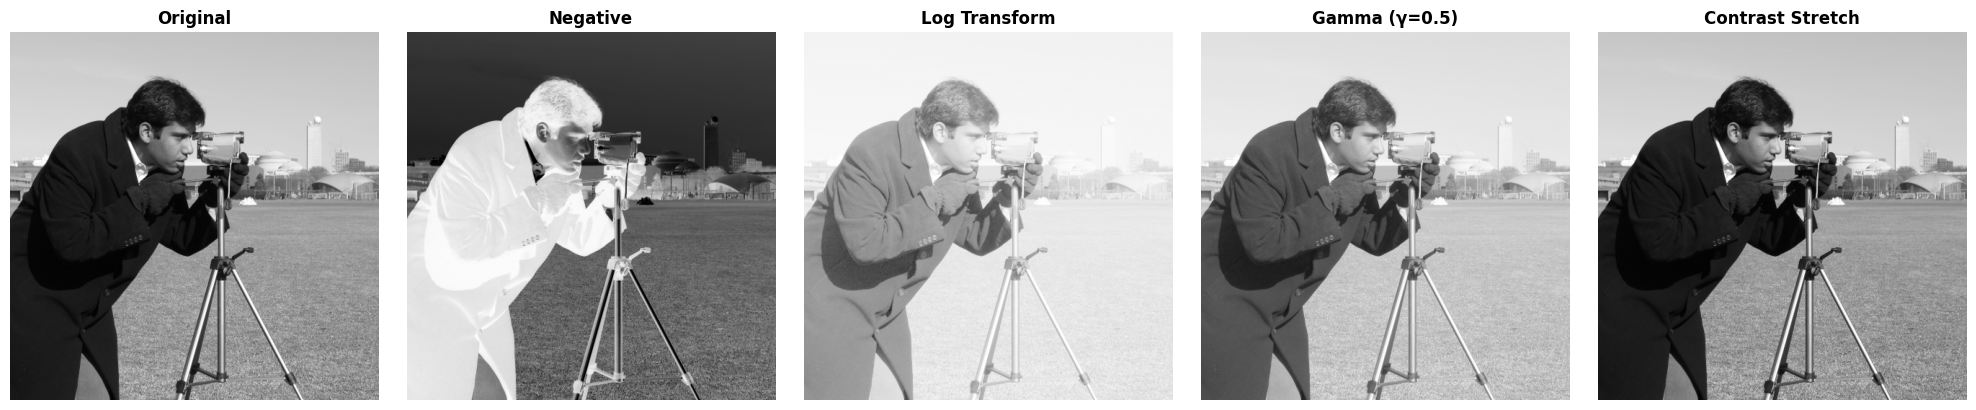

 Intensity Transformations complete.


In [2]:
# Intensity Transformations (Negative, Log, Power/Gamma, Contrast Stretching)
def intensity_transformations(img):
    img = img.astype(np.float64)
    L = 256 # gray levels

    # 1. Image Negative
    negative = L - 1 - img

    # 2. Log Transformation: s = c * log(1 + r)
    c = (L - 1) / np.log(1 + np.max(img))
    log_img = c * np.log(1 + img)

    # 3. Power-Law (Gamma) Transformation: s = c * r^gamma
    gamma = 0.5 # <1 brightens, >1 darkens
    c = 1.0
    gamma_img = c * np.power(img / 255.0, gamma) * 255

    # 4. Contrast Stretching: linear stretch to [0, 255]
    r_min, r_max = img.min(), img.max()
    contrast = (img - r_min) / (r_max - r_min) * 255

    images = [
    img.astype(np.uint8),
    negative.astype(np.uint8),
    log_img.astype(np.uint8),
    gamma_img.astype(np.uint8),
    contrast.astype(np.uint8)
    ]
    titles = ['Original', 'Negative', 'Log Transform',
              f'Gamma (γ={gamma})', 'Contrast Stretch']

    show(images, titles, figsize=(20, 4))
    print(" Intensity Transformations complete.")

intensity_transformations(img_gray)